In [12]:
%load_ext autoreload
%autoreload 2

import src.data as data
import src.testes as testes
import src.viz as viz
import src.models as models
import src.data as data


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
CAMINHO_TRAIN = "dados/treino.csv"
CAMINHO_VAL = "dados/validacao.csv"

DATA_FIM_TRAIN = "2016-03-27"

DATA_INICIO_VAL = "2016-03-28"
DATA_FIM_VAL = "2016-04-24"

In [14]:
train_data = data.carregar_dados_e_tratar_data(
    caminho=CAMINHO_TRAIN, data_fim=DATA_FIM_TRAIN
)
val_data = data.carregar_dados_e_tratar_data(
    caminho=CAMINHO_VAL, data_inicio=DATA_INICIO_VAL, data_fim=DATA_FIM_VAL
)

full_data = data.construir_full_data(train_data, val_data)

In [15]:
print(train_data.head())

        date  store_total  FOODS  HOBBIES
0 2011-01-29         4337   3239      556
1 2011-01-30         4155   3137      498
2 2011-01-31         2816   2008      415
3 2011-02-01         3051   2258      392
4 2011-02-02         2630   2032      268


In [16]:
print(val_data.head())

        date  store_total  FOODS  HOBBIES
0 2016-03-28         3905   2480      535
1 2016-03-29         3788   2481      498
2 2016-03-30         3339   2135      465
3 2016-03-31         4076   2651      536
4 2016-04-01         4983   3132      743


In [17]:
testes.verificar_consistencia(
    train_data,
    val_data,
    data_fim1=DATA_FIM_TRAIN,
    data_inicio2=DATA_INICIO_VAL,
    data_fim2=DATA_FIM_VAL,
)

SUCESSO: Os dados estão consistentes (Do tipo correto, ordenados, com datas únicas, no intervalo correto e sem vazamentos)


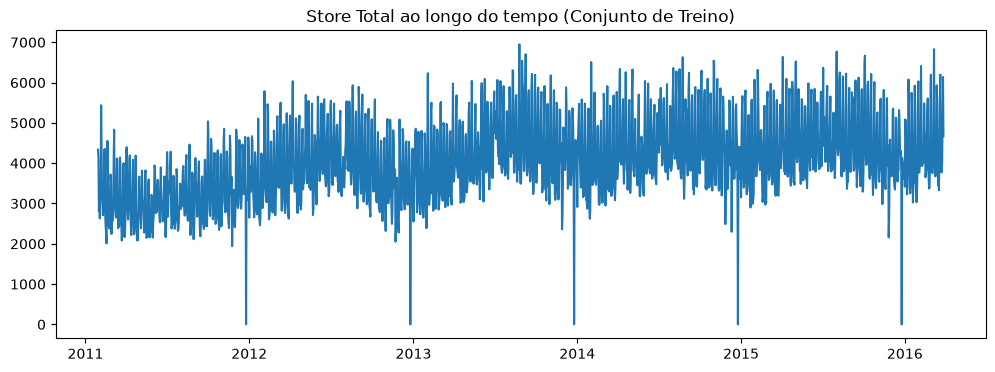

In [18]:
viz.grafico_temporal(
    train_data["store_total"],
    train_data["date"],
    titulo="Store Total ao longo do tempo (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
)

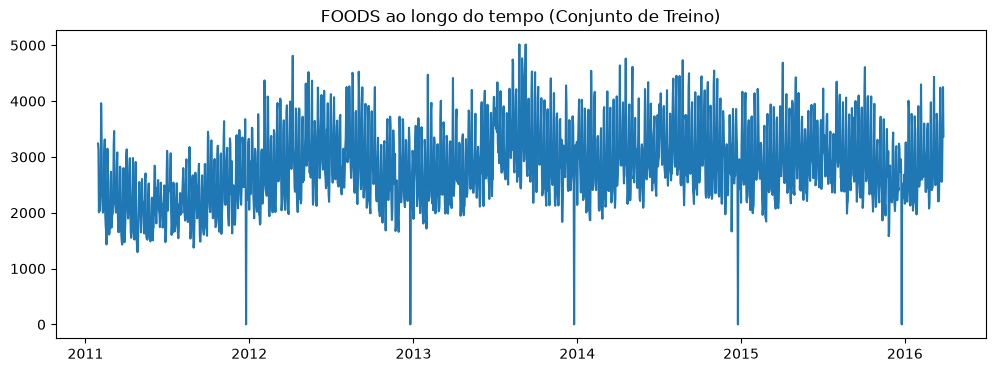

In [19]:
viz.grafico_temporal(
    train_data["FOODS"],
    train_data["date"],
    titulo="FOODS ao longo do tempo (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
)

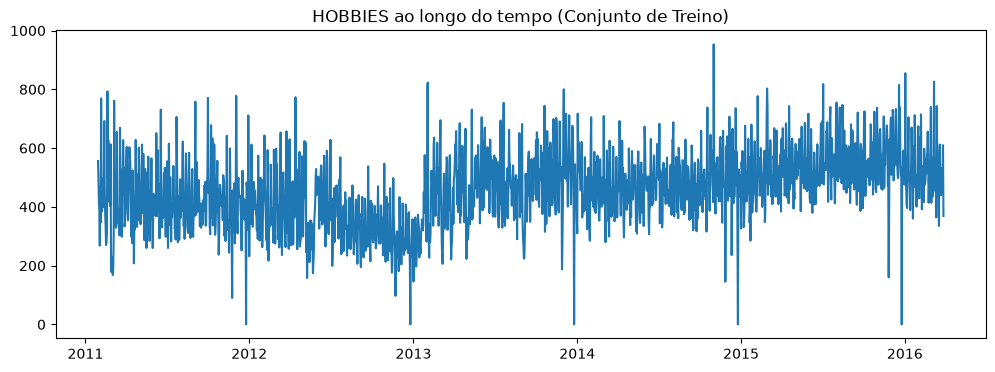

In [20]:
viz.grafico_temporal(
    train_data["HOBBIES"],
    train_data["date"],
    titulo="HOBBIES ao longo do tempo (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
)

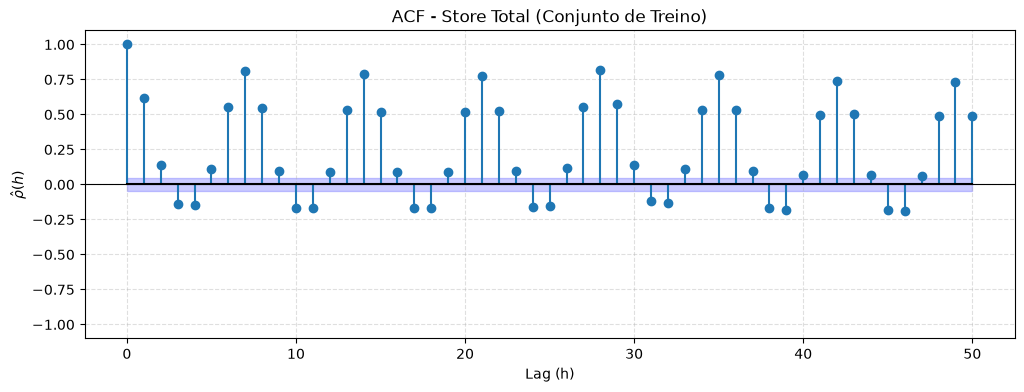

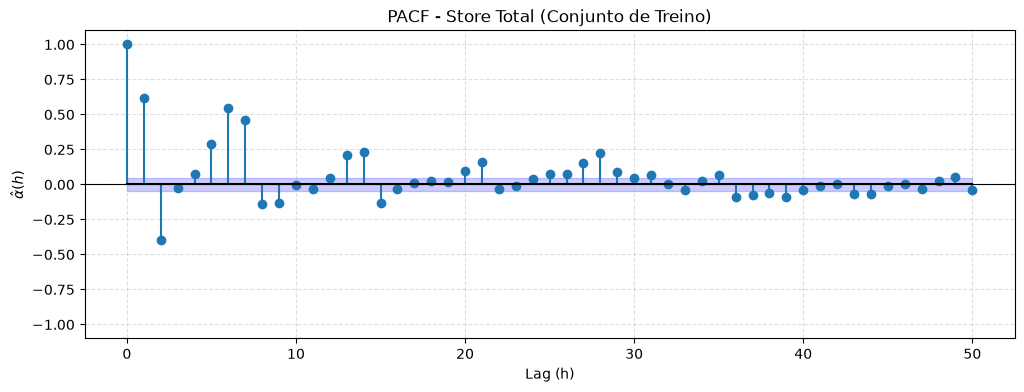

In [21]:
# ACF e PACF para o Store Total no conjunto de treino

viz.grafico_ACF(
    train_data["store_total"],
    train_data["date"],
    titulo="ACF - Store Total (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

viz.grafico_PACF(
    train_data["store_total"],
    train_data["date"],
    titulo="PACF - Store Total (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

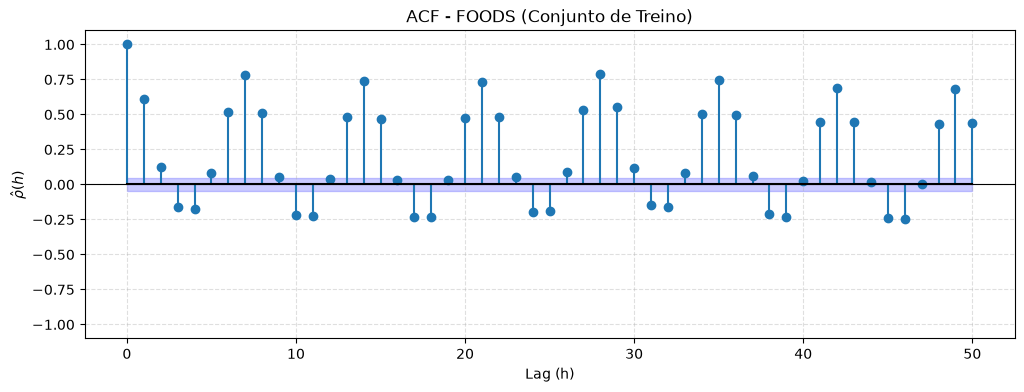

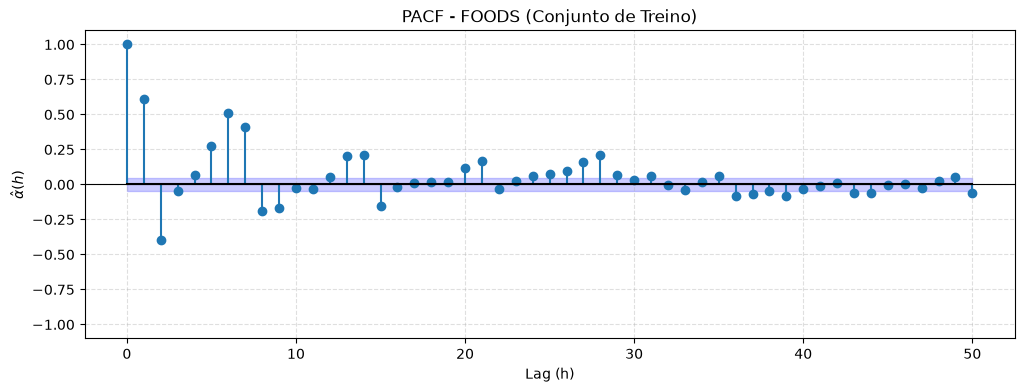

In [22]:
# ACF e PACF para a categoria FOODS no conjunto de treino

viz.grafico_ACF(
    train_data["FOODS"],
    train_data["date"],
    titulo="ACF - FOODS (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

viz.grafico_PACF(
    train_data["FOODS"],
    train_data["date"],
    titulo="PACF - FOODS (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

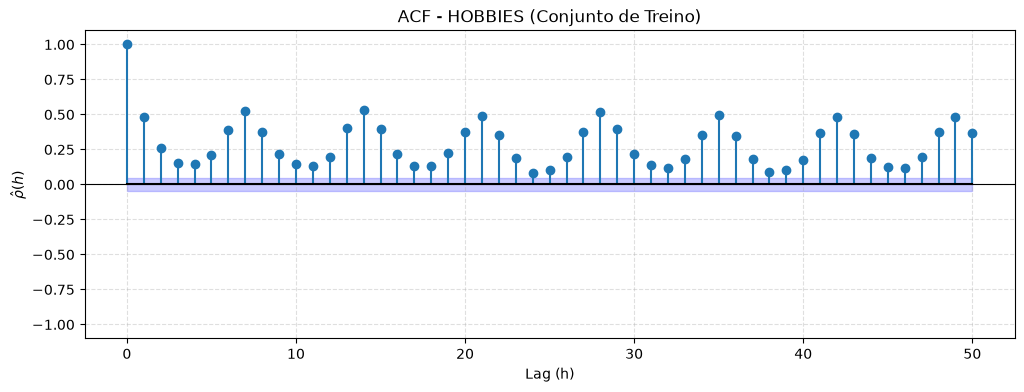

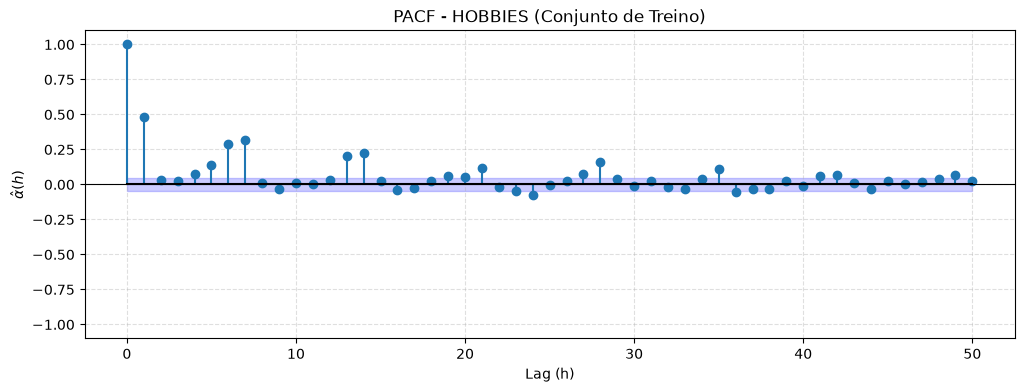

In [23]:
# ACF e PACF para a categoria HOOBIES no conjunto de treino

viz.grafico_ACF(
    train_data["HOBBIES"],
    train_data["date"],
    titulo="ACF - HOBBIES (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

viz.grafico_PACF(
    train_data["HOBBIES"],
    train_data["date"],
    titulo="PACF - HOBBIES (Conjunto de Treino)",
    data_inicio=None,
    data_fim=None,
    nlags=50,
)

Baselines Models

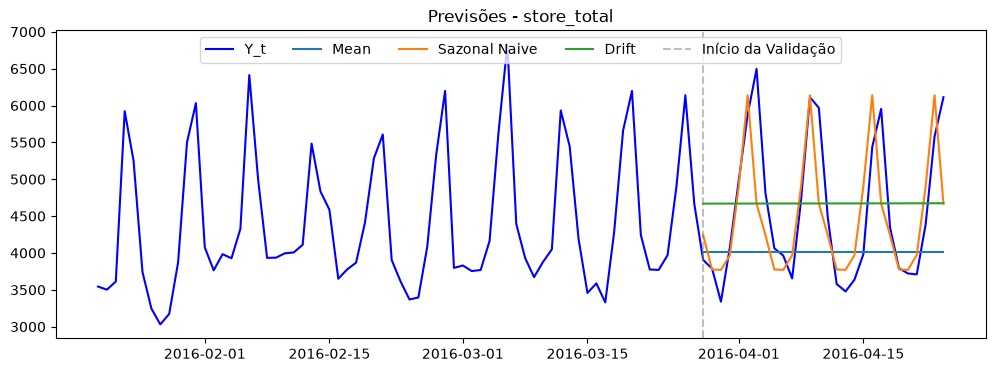

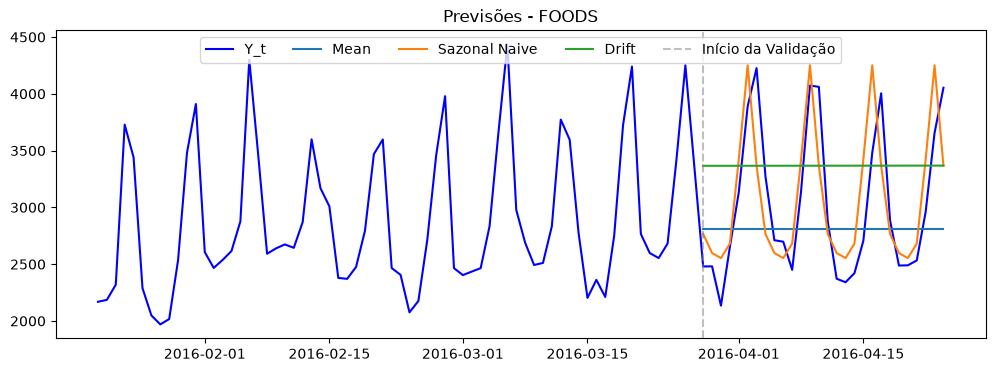

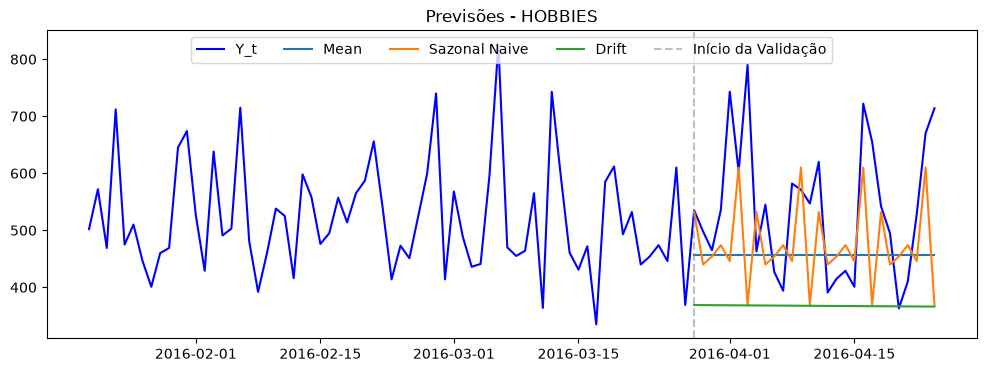

In [24]:
labels = full_data.columns[1:]

for label in labels:
    previsoes = {"Mean": models.mean(train_data[label], n=len(val_data)),
                 # "Naive": models.naive(train_data[label], n=len(validation_data)),
                 "Sazonal Naive": models.naive_sazonal(train_data[label], m=7, n=len(val_data)),
                 "Drift": models.drift(train_data[label], n=len(val_data))
	}
    
    viz.grafico_temporal_com_previsao(
        full_data[label],
        full_data["date"],
        previsoes,
		val_data["date"],
        titulo=f"Previsões - {label}",
		data_inicio="2016-01-20",
		data_fim=None
)
